In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
CLASS_MAPS = {
    "person": 0,
    "table": 1,
    "potted plant": 2,
    "chair": 3,
    "sofa": 4,
    "lamp": 5,
    "door": 6,
    "cabinet": 7,
    "wardrobe": 8,
    "refrigerator": 9,
    "bed": 10
}
CLASS_MAPS = {v: k for k, v in CLASS_MAPS.items()}
CLASS_MAPS

{0: 'person',
 1: 'table',
 2: 'potted plant',
 3: 'chair',
 4: 'sofa',
 5: 'lamp',
 6: 'door',
 7: 'cabinet',
 8: 'wardrobe',
 9: 'refrigerator',
 10: 'bed'}

In [4]:
train_dir = "E:/dsai_group4_project/datasets/dsai-unified-dataset/labels"

label_files = (
    [os.path.join(train_dir, f) for f in os.listdir(train_dir)]
)

In [6]:
class_counts = {class_name: 0 for class_name in CLASS_MAPS.values()}
for i, label_file in enumerate(label_files):
    with open(label_file, 'r') as f:
        anotations = [line for line in f.read().split("\n") if line.strip() != ""]
        class_ids = set([int(line.split(" ")[0]) for line in anotations])
        for class_id in class_ids:
            class_name = CLASS_MAPS[class_id]
            class_counts[class_name] += 1
print(class_counts)

{'person': 4922, 'table': 3405, 'potted plant': 2425, 'chair': 2675, 'sofa': 2222, 'lamp': 1281, 'door': 828, 'cabinet': 562, 'wardrobe': 485, 'refrigerator': 2516, 'bed': 1394}


In [7]:
class_counts = pd.Series(class_counts)
class_counts.sort_values(ascending=False)

person          4922
table           3405
chair           2675
refrigerator    2516
potted plant    2425
sofa            2222
bed             1394
lamp            1281
door             828
cabinet          562
wardrobe         485
dtype: int64

<Axes: >

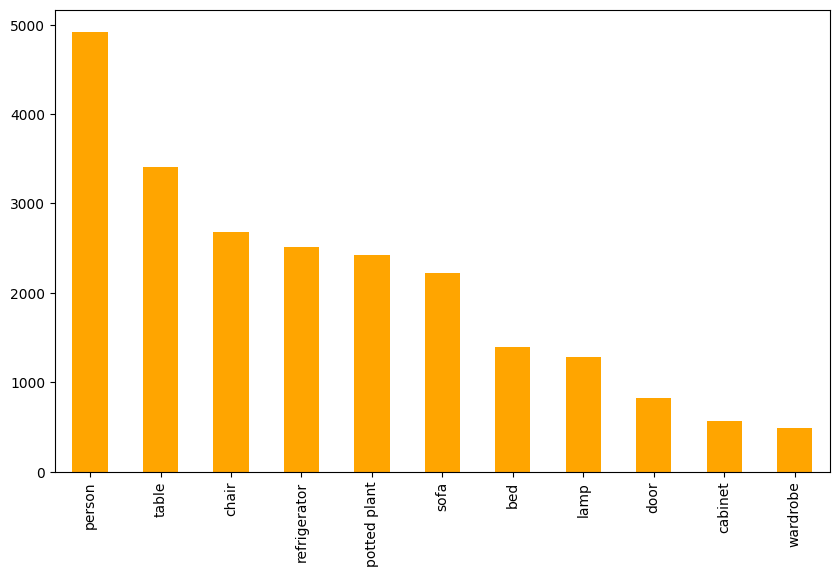

In [9]:
class_counts.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6), color='orange')